# **AirBNB Price Prediction**

## Collaborateurs
- Conambot NGUESSAN
- Julie SAINT MARTIN
- Rémi KORZENIOWSKI
- Seer MENSAH-ASSIAKOLEY

## Dépot github : [PIA projet final M102](https://github.com/Thekorzeremi/PIA_Projet_final_M102)

In [1]:
# imports and variables constantes
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, joblib
from pathlib import Path
import gzip
import shutil
import time
from datetime import datetime
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.metrics import r2_score as r2_score_f
from scipy.stats import loguniform, randint

SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

print("Setup OK · Versions :")
import sklearn; print(f"  scikit-learn : {sklearn.__version__}")
print(f"  pandas       : {pd.__version__}")
print(f"  numpy        : {np.__version__}")

Setup OK · Versions :
  scikit-learn : 1.8.0
  pandas       : 3.0.3
  numpy        : 2.4.6


In [2]:
# fonctions utilitaires
def decompress_gz(fichier_entree: Path):
    with gzip.open(fichier_entree, 'rb') as f_in:
        with open(fichier_entree.with_suffix(''), 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

### Dataset

In [3]:
# Chemin vers les fichiers de dataset sur Paris
archive_dataset = "data/listings.csv.gz"
csv_fallback = "data/listings.csv"

In [4]:
# chargement des data
try:
    path = Path(archive_dataset)
    decompress_gz(path)
finally:
    df = pd.read_csv(csv_fallback)
    print(f"✓ Chargé depuis CSV : {df.shape}")

✓ Chargé depuis CSV : (84055, 79)


## EDA

In [6]:
df_data = df.copy()
df_data.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 84055 entries, 0 to 84054
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            84055 non-null  int64  
 1   listing_url                                   84055 non-null  str    
 2   scrape_id                                     84055 non-null  int64  
 3   last_scraped                                  84055 non-null  str    
 4   source                                        84055 non-null  str    
 5   name                                          84055 non-null  str    
 6   description                                   81177 non-null  str    
 7   neighborhood_overview                         41178 non-null  str    
 8   picture_url                                   84054 non-null  str    
 9   host_id                                       84055 non-null  int64  
 1

In [ ]:
df.info()

### Suppression de colonnes inutiles

In [8]:
# On dégage la colonne Id qui n'a aucune valeur prédictive
columns_id = [col for col in df_data.columns if col.endswith('id') ]
print(f"Shape avant: {df_data.shape}")
print('Colonnes d\'id :', columns_id) 
for c in columns_id:
    df_data = df_data.drop(columns=[c])
print(f"Shape après: {df_data.shape}")

                         listing_url last_scraped           source                                             name                                        description  \
0  https://www.airbnb.com/rooms/3109   2025-06-20      city scrape                                     zen and calm  Lovely Appartment with one bedroom with a Quee...   
1  https://www.airbnb.com/rooms/5396   2025-06-19      city scrape     Your perfect Paris studio on Île Saint-Louis  Cozy, well-appointed and graciously designed s...   
2  https://www.airbnb.com/rooms/7397   2025-06-20      city scrape                 MARAIS - 2ROOMS APT - 2/4 PEOPLE          VERY CONVENIENT, WITH THE BEST LOCATION !   
3  https://www.airbnb.com/rooms/7964   2025-06-18  previous scrape                     Sunny apartment with balcony  We are renting our a spacious, sunny fully fur...   
4  https://www.airbnb.com/rooms/9359   2025-06-18      city scrape  Cozy, Central Paris: WALK or VELIB EVERYWHERE !  Location! Location! Location! Jus

,listing_url,last_scraped,source,name,description,neighborhood_overview,picture_url,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,...,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,property_type,room_type,bathrooms_text,amenities,price,has_availability,calendar_last_scraped,first_review,last_review,license,instant_bookable
count,84055,84055,84055,84055,81177,41178,84054,84055,84031,84029,66876,37408,52663,52663,57913,...,84029,84029,41178,84055,84055,84055,83982,84055,53963,79903,84055,64498,64498,66434,84055
unique,84055,5,2,77999,77228,35729,83370,60884,11376,5381,1935,21566,4,93,101,...,2,2,1,20,58,4,36,73151,1634,2,5,4598,3449,54163,2
top,https://www.airbnb.com/rooms/3109,2025-06-18,city scrape,Appartement,"Make life easier at this peaceful, centrally l...",.,https://a0.muscache.com/pictures/miso/Hosting-...,https://www.airbnb.com/users/show/314994947,Joffrey Sally,2019-12-06,"Paris, France","We’re Blueground, a global proptech company wi...",within an hour,100%,100%,...,t,t,Neighborhood highlights,Buttes-Montmartre,Entire rental unit,Entire home/apt,1 bath,"[""Kitchen"", ""Wifi"", ""Washer"", ""Smoke alarm"", ""...",$90.00,t,2025-06-18,2024-08-04,2025-06-01,"Available with a mobility lease only (""bail mo...",f
freq,1,35435,54313,91,116,84,7,835,1018,853,57893,835,31859,36805,21028,...,81146,75982,41178,8943,69871,74532,61261,339,801,79902,35435,227,2510,7482,61484


In [9]:
# Sélection des colonnes de type 'object'
df_objects = df_data.select_dtypes(include=['object'])

# Afficher les premières lignes pour vérifier les valeurs
print(df_objects.head())

# Optionnel : obtenir un résumé rapide des valeurs uniques par colonne
display(df_objects.describe())

np.int64(29758)

In [10]:
# verifions les NA
df_data['bathrooms'].isnull().sum()

Shape avant: (84055, 76)
Shape après: (84055, 42)


In [ ]:
# Columns inutiles
print(f"Shape avant: {df_data.shape}")
cols_to_drop = [
    'listing_url', 'last_scraped','source', 'name', 'picture_url', 'host_url', 'host_name', 
    'neighbourhood_group_cleansed', 'beds', 'calendar_updated', 
    'description', 'neighborhood_overview', 'neighbourhood', 'host_about', 
    'host_thumbnail_url', 'host_picture_url', 'minimum_nights_avg_ntm', 
    'maximum_nights_avg_ntm', 'calendar_last_scraped', 'has_availability', 
    'reviews_per_month', 'license', 'host_neighbourhood', 'host_location',
    'host_since', 'first_review', 'last_review', 'host_verifications',
    'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 
    'maximum_minimum_nights', 'minimum_maximum_nights',	'maximum_maximum_nights',
]
# On utilise errors='ignore' au cas où certaines auraient déjà été supprimées
df_data = df_data.drop(columns=cols_to_drop, errors='ignore')
print(f"Shape après: {df_data.shape}")

**Pourquoi on les supprime:**

#### 1. Identifiants uniques (sans pouvoir prédictif)
- `id`, `listing_url`, `scrape_id`, `picture_url`, `host_url`, `host_thumbnail_url`, `host_picture_url`  
  → Ce sont des clés ou URLs propres à chaque annonce. Elles n’influencent pas le prix et suradapteraient le modèle (chaque ligne devient unique).

#### 2. Colonnes textuelles longues et non structurées
- `name`, `description`, `neighborhood_overview`, `host_about`, `host_verifications` (liste)  
  → Trop de cardinalité, nécessiteraient un NLP lourd. Le gain pour la prédiction du prix est faible comparé à des features structurées (type de logement, nombre de chambres, localisation…). Souvent supprimées pour rester simple.

#### 3. Dates et métadonnées temporelles (fuite de données)
- `last_scraped`, `calendar_last_scraped`, `first_review`, `last_review`, `host_since`  
  → Si tu veux prédire le prix *actuel*, ces dates ne sont pas connues à l’avance ou créent une fuite (ex: `last_review` dépend des futures reviews). De plus, leur transformation en âge (ex: ancienneté hôte) peut être ajoutée plus tard si vraiment utile, mais souvent on les supprime d’abord.

#### 4. Colonnes avec trop de valeurs manquantes ou quasi vides
- `neighbourhood_group_cleansed` (0 non‑null), `calendar_updated` (0 non‑null)  
  → Aucune information, suppression évidente.
- `beds` (54k non‑null sur 84k) → déjà remplacée ? `beds` est une redondance de `bedrooms` + `bathrooms` ; en plus `bedrooms` est mieux remplie (76k). Donc `beds` peut sauter.

#### 5. Colonnes dérivées / agrégées inutiles pour la prédiction
- `minimum_nights_avg_ntm`, `maximum_nights_avg_ntm`  
  → Ce sont des moyennes calculées sur des périodes mobiles, très corrélées avec `minimum_nights` et `maximum_nights` (qui restent). La version “avg_ntm” peut causer une fuite (moyenne future).
- `reviews_per_month`  
  → Calculé à partir de `number_of_reviews` et de l’âge de l’annonce. Il n’est pas disponible pour une prédiction en temps réel (sauf si tu reconstruis), et `number_of_reviews` suffit.

#### 6. Colonnes redondantes ou trop spécifiques
- `neighbourhood` (non nettoyé) vs `neighbourhood_cleansed` (version standardisée)  
  → Garde la version cleansed, jette l’autre.
- `host_neighbourhood` (trop de manquantes, redondante avec `neighbourhood_cleansed`)
- `host_location` (texte libre, peu fiable)
- `license` (beaucoup de NaN, non pertinent pour la majorité des annonces)
- `has_availability` (booléen souvent toujours True, ou alors redondant avec `availability_30/60/90/365`)

#### 7. Colonnes liées aux durées minimales/maximales (multiples versions)
- `minimum_nights`, `maximum_nights` (gardées)
- `minimum_minimum_nights`, `maximum_minimum_nights`, `minimum_maximum_nights`, `maximum_maximum_nights`  
  → Trop de granularité (min du min, max du min…). En général on ne garde que `minimum_nights` et `maximum_nights` pour un modèle simple. Les autres sont des métadonnées de calendrier avancées dont tu n’as pas besoin.

#### 8. Colonnes qui ne servent qu’à la qualité des données (pas à la prédiction)
- `source` (d’où vient l’annonce ? peu informatif)
- `calendar_updated` (toujours vide)
- `host_verifications` (liste, trop complexe)

## Résumé
On a gardé principalement :  
- localisation (`latitude`, `longitude`, `neighbourhood_cleansed`)  
- caractéristiques physiques (`property_type`, `room_type`, `accommodates`, `bedrooms`, `bathrooms`)  
- équipements (`amenities` – à encoder proprement)  
- disponibilité (`availability_30/60/90/365`)  
- historique des reviews (`number_of_reviews`, `review_scores_*`)  
- et la cible `price` (après nettoyage).

C’est une base saine et non‑polluée pour un premier modèle de prédiction de prix. Bravo !


In [12]:
# Vérification
print("Shape :", df_data.shape)
display(df_data.describe())
df_data.info()

host_response_time                              31392
host_response_rate                              31392
host_acceptance_rate                            26142
host_is_superhost                                1828
host_listings_count                                26
host_total_listings_count                          26
host_has_profile_pic                               26
host_identity_verified                             26
neighbourhood_cleansed                              0
latitude                                            0
longitude                                           0
property_type                                       0
room_type                                           0
accommodates                                        0
bathrooms                                       29758
bathrooms_text                                     73
bedrooms                                         7137
amenities                                           0
price                       

In [ ]:
# verifions les NA
df_data.isnull().sum()

### Parsing 

In [14]:
# Parsing du prix 
df_data['price'] = df_data['price'].str.replace(r'[\$,]', '', regex=True).astype(float)

In [15]:

# Parsing de colonnes contenant des valeurs en pourcentage mais sous format str 
df_data['host_acceptance_rate'] = df_data['host_acceptance_rate'].str.replace('%', '', regex=False).astype('Int64')
df_data['host_response_rate'] = df_data['host_response_rate'].str.replace('%', '', regex=False).astype('Int64')

In [16]:
# Parsing de bathrooms_text
extracted_bathrooms = df_data['bathrooms_text'].str.extract(r'(\d+\.?\d*)')[0].astype(float)

# Remplir les valeurs manquantes (NaN) dans 'bathrooms' avec les valeurs extraites
# Si 'bathrooms' a déjà une valeur, on la garde. Si c'est NaN, on prend l'extraction.
df_data['bathrooms'] = df_data['bathrooms'].fillna(extracted_bathrooms)

# Traitement spécifique pour les cas particuliers (ex: "Half-bath" qui devient souvent NaN)
# Si après l'étape précédente, il reste des NaN et que le texte contenait "half"
df_data.loc[df_data['bathrooms'].isna() & df_data['bathrooms_text'].str.contains('half', case=False, na=False), 'bathrooms'] = 0.5

# Nettoyage final : Remplacer les restants par 0 si nécessaire (selon votre logique métier)
df_data['bathrooms'] = df_data['bathrooms'].fillna(0)

# On supprime la colonne texte après avoir récupéré les infos
df_data = df_data.drop(columns=['bathrooms_text'])

In [17]:
# colonnes à changer en binaire
cols_bool = ['host_has_profile_pic', 'host_identity_verified', 'host_is_superhost', ]
for col in cols_bool:
    # Le map transforme 't' en 1 et 'f' en 0. Les valeurs manquantes restent NaN pour le moment.
    df_data[col] = df_data[col].map({'t': 1, 'f': 0})

["Shampoo", "Long term stays allowed", "Portable fans", "Washer", "Oven", "Clothing storage: closet", "Hair dryer", "Stove", "Fire extinguisher", "Coffee", "Coffee maker: espresso machine, pour-over coffee", "Drying rack for clothing", "Bed linens", "Baking sheet", "Host greets you", "First aid kit", "Kitchen", "Dishes and silverware", "Toaster", "Shower gel", "Body soap", "Cleaning products", "Hangers", "Wifi", "Wine glasses", "Hot water kettle", "TV with standard cable", "Books and reading material", "Hot water", "Iron", "Heating", "Smoke alarm", "Essentials", "Extra pillows and blankets", "Dedicated workspace", "Cooking basics", "Refrigerator"]


count                                                 84055
unique                                                73151
top       ["Kitchen", "Wifi", "Washer", "Smoke alarm", "...
freq                                                    339
Name: amenities, dtype: object

In [18]:
# Sélection des colonnes de type 'object'
df_amen = df_data['amenities']

# Afficher les premières lignes pour vérifier les valeurs
print(df_amen[1])

# Optionnel : obtenir un résumé rapide des valeurs uniques par colonne
display(df_amen.describe())

Shape avant: (84055, 41)
Shape après: (84055, 58)


,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,...,has_ac,has_elevator,has_shampoo,has_washer,has_oven,has_stove,has_hair_dryer,has_iron,has_heating,has_coffee_maker,has_refrigerator,has_workspace,has_fire_extinguisher,has_smoke_alarm,has_first_aid
0,within an hour,100,100,0.0,1.0,1.0,1.0,1.0,Observatoire,48.83191,2.31870,Entire rental unit,Entire home/apt,2,1.0,...,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0
1,within an hour,100,95,0.0,2.0,4.0,1.0,1.0,Hôtel-de-Ville,48.85247,2.35835,Entire rental unit,Entire home/apt,2,1.0,...,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1
2,within an hour,100,67,1.0,1.0,10.0,1.0,1.0,Hôtel-de-Ville,48.85909,2.35315,Entire rental unit,Entire home/apt,4,1.0,...,0,0,1,1,1,1,1,1,1,1,1,1,0,1,0
3,NaN,<NA>,<NA>,0.0,1.0,1.0,1.0,1.0,Opéra,48.87417,2.34245,Entire rental unit,Entire home/apt,3,1.0,...,0,0,0,1,1,1,1,1,1,1,1,1,0,0,0
4,NaN,<NA>,<NA>,0.0,2.0,4.0,1.0,1.0,Louvre,48.86006,2.34863,Entire rental unit,Entire home/apt,1,1.0,...,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0


In [ ]:
# Parsing des amenities
# On définit un dictionnaire avec le nom de la future colonne et le mot-clé à chercher

print(f"Shape avant: {df_data.shape}")
amenities_to_extract = {
    'has_wifi': 'Wifi',
    'has_tv': 'TV',
    'has_kitchen': 'Kitchen',
    'has_ac': 'Air conditioning',
    'has_elevator': 'Elevator',
    'has_shampoo': 'Shampoo',
    'has_washer': 'Washer',
    'has_oven': 'Oven',
    'has_stove': 'Stove',
    'has_hair_dryer': 'Hair dryer',
    'has_iron': 'Iron',
    'has_heating': 'Heating',
    'has_coffee_maker': 'Coffee maker',
    'has_refrigerator': 'Refrigerator',
    'has_workspace': 'Dedicated workspace',
    'has_fire_extinguisher': 'Fire extinguisher',
    'has_smoke_alarm': 'Smoke alarm',
    'has_first_aid': 'First aid kit'
}

for col_name, keyword in amenities_to_extract.items():
    # str.contains cherche le mot-clé. na=False permet de mettre 0 si la ligne est NaN.
    # astype(int) transforme le True/False en 1/0
    df_data[col_name] = df_data['amenities'].str.contains(keyword, case=False, na=False).astype(int)

# On supprime la colonne JSON brute qui n'est plus utile pour le modèle
df_data = df_data.drop(columns=['amenities'])
print(f"Shape après: {df_data.shape}")
df_data.head(5)

### Verification des valeurs manquantes

In [20]:
# calcul des corrélations
df_data_copy = df_data.copy()
corrs = df_data_copy.select_dtypes(include=np.number).corr()['price'].sort_values(ascending=False)
SEUIL_CORR = 0.02

In [21]:

missing = (
    df_data_copy.isnull()
    .sum()
    .reset_index()
    .rename(columns={'index': 'feature', 0: 'missing_count'})
)

df_data_copy.head

# print(missing)

missing['column_type'] = missing['feature'].map(df_data_copy.dtypes.astype(str))
missing['na_percentage'] = missing['missing_count'] / len(df_data_copy) * 100
missing['price_correlation'] = missing['feature'].map(corrs)

,feature,missing_count,column_type,na_percentage,price_correlation
16,price,30092,float64,35.800369,1.000000
27,estimated_revenue_l365d,30092,float64,35.800369,0.464334
15,bedrooms,7137,float64,8.490869,0.205691
4,host_listings_count,26,float64,0.030932,0.068375
5,host_total_listings_count,26,float64,0.030932,0.067636


,feature,missing_count,column_type,na_percentage,price_correlation


In [22]:
display(
    missing.loc[
        (missing['price_correlation'] > SEUIL_CORR) & (missing['missing_count'] > 0)
    ].sort_values('price_correlation', ascending=False)
)

display(
    missing.loc[
        (missing['price_correlation'] < (-1. *SEUIL_CORR)) & (missing['missing_count'] > 0)
    ]
)

(58, 5)


,feature,missing_count,column_type,na_percentage,price_correlation
0,host_response_time,31392,str,37.346975,NaN
1,host_response_rate,31392,Int64,37.346975,0.008692
2,host_acceptance_rate,26142,Int64,31.101065,0.047423
3,host_is_superhost,1828,float64,2.174767,-0.026041
4,host_listings_count,26,float64,0.030932,0.068375
5,host_total_listings_count,26,float64,0.030932,0.067636
6,host_has_profile_pic,26,float64,0.030932,-0.000433
7,host_identity_verified,26,float64,0.030932,0.004752
8,neighbourhood_cleansed,0,str,0.000000,NaN
9,latitude,0,float64,0.000000,-0.004586


In [ ]:
print(missing.shape)
display(missing.head(20))

### Strategie pour les missings

On garde toutes les features > et/ou < 0.02 et les coordonnées

## NA Strategy

|NA row|strategy|
|-----|-----|
|price|delete row|
|estimated_revenue_l365d|delete row|
|bathrooms|remplace par 0|
|bedrooms|remplace par 1|
|host_listings_count|delete row|
|host_total_listings_count|delete row|

### Strategie numérique

In [24]:
display(df_data_copy)

['host_listings_count', 'host_total_listings_count', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'price', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'has_tv', 'has_kitchen', 'has_ac', 'has_fire_extinguisher']
removed  host_listings_count
removed  host_total_listings_count
removed  longitude
removed  accommodates
removed  bathrooms
removed  bedrooms
removed  price
removed  availability_30
removed  availability_60
removed  availability_90
removed  availability_365
removed  availability_eoy
removed  number_of_reviews_ly
removed  estimated_occupancy_l365d
removed  estimated_revenue_l365d
removed  has_tv
removed  has_kitchen
removed  has_ac
removed  has_fire_extinguisher
Index(['host_listings_count', 'host_total_listings_count', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'price', 'availability_30', 'availability_60', 'availability_90', 'a

In [25]:
selected_cols_corr = missing.loc[missing['price_correlation'].abs() > SEUIL_CORR, 'feature'].dropna().tolist()
print(selected_cols_corr)

col_to_r = []

count = 0

for col in df_data_copy.columns :
    col_to_r.append(col)

for scol in selected_cols_corr :
    col_to_r.remove(scol)
    print("removed ", scol)
       
df_data_copy = df_data_copy.drop(columns=col_to_r)

print(df_data_copy.columns)

# NA Strategies
df_data_copy = df_data_copy.dropna(subset=['price', 'estimated_revenue_l365d', 'host_listings_count', 'host_total_listings_count'])
df_data_copy.isnull().sum().sort_values(ascending=False)
df_data_copy['bathrooms'] = df_data_copy['bathrooms'].fillna(0)
df_data_copy['bedrooms'] = df_data_copy['bedrooms'].fillna(1)

After cleaner:  19
(53953, 19)


,host_listings_count,host_total_listings_count,longitude,accommodates,bathrooms,bedrooms,price,availability_30,availability_60,availability_90,availability_365,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,has_tv,has_kitchen,has_ac,has_fire_extinguisher
0,1.0,1.0,2.318700,2,1.0,1.0,135.0,20,50,80,355,185,0,31,4185.0,0,1,0,0
1,2.0,4.0,2.358350,2,1.0,0.0,114.0,7,37,54,69,69,52,255,29070.0,1,1,0,1
2,1.0,10.0,2.353150,4,1.0,2.0,149.0,0,12,27,197,122,24,255,37995.0,1,1,0,0
4,2.0,4.0,2.348630,1,1.0,1.0,75.0,23,53,83,358,190,0,0,0.0,0,1,0,0
5,1.0,3.0,2.358670,1,1.0,1.0,50.0,21,51,81,82,82,2,31,1550.0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84050,9.0,15.0,2.291000,1,1.0,1.0,78.0,5,5,5,5,5,0,0,0.0,0,1,0,0
84051,1.0,1.0,2.374200,2,1.0,1.0,89.0,17,47,77,352,184,0,0,0.0,0,1,0,0
84052,1.0,1.0,2.334080,4,1.0,1.0,105.0,10,28,58,333,165,0,0,0.0,1,1,0,0
84053,1.0,2.0,2.381301,3,1.0,1.0,100.0,16,31,31,195,123,0,0,0.0,0,1,0,0


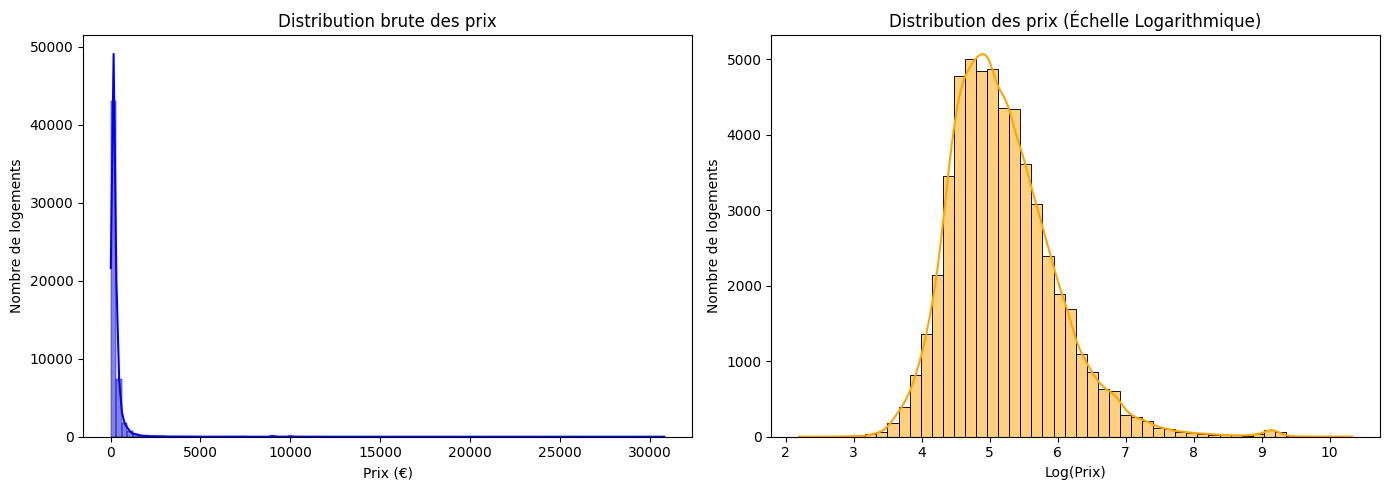

In [26]:
print("After cleaner: ", len(df_data_copy.columns))
print(df_data_copy.shape)

display(df_data_copy)

In [ ]:
# Distribution des prix

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df_data_copy, x='price', bins=100, kde=True, color='blue')
plt.title('Distribution brute des prix')
plt.xlabel('Prix (€)')
plt.ylabel('Nombre de logements')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df_data_copy['price'].dropna()), bins=50, kde=True, color='orange')
plt.title('Distribution des prix (Échelle Logarithmique)')
plt.xlabel('Log(Prix)')
plt.ylabel('Nombre de logements')

plt.tight_layout()
plt.show()

### Strategie Catégoritielle

In [28]:
# Sélection des colonnes de type 'object'
df_objects = df_data.select_dtypes(include=['object'])

# Afficher les premières lignes pour vérifier les valeurs
print(df_objects.head())

# Optionnel : obtenir un résumé rapide des valeurs uniques par colonne
display(df_objects.describe())

=== VALEURS MANQUANTES (TEXTE) ===
host_response_time        31392
neighbourhood_cleansed        0
property_type                 0
room_type                     0
instant_bookable              0
dtype: int64




In [29]:
# --- 1. DIAGNOSTIC DES COLONNES TEXTE (STR) ---
# On sélectionne uniquement les colonnes de type 'object' (texte)
cols_texte = df_data.select_dtypes(include=['object'])

print("=== VALEURS MANQUANTES (TEXTE) ===")
print(cols_texte.isna().sum())
print("\n" + "="*35 + "\n")


Nombre de colonnes finales : 24
Colonnes présentes : ['host_listings_count', 'host_total_listings_count', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'price', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'has_tv', 'has_kitchen', 'has_ac', 'has_fire_extinguisher', 'host_response_time', 'neighbourhood_cleansed', 'property_type', 'room_type', 'instant_bookable']


In [ ]:
# 
cols_object_original = df_data.select_dtypes(include=['object']).columns

cols_to_add = [col for col in cols_object_original if col not in df_data_copy.columns]

df_final = df_data_copy.join(df_data[cols_to_add])

# Vérification
print(f"Nombre de colonnes finales : {df_final.shape[1]}")
print(f"Colonnes présentes : {df_final.columns.tolist()}")

### Histogrammes

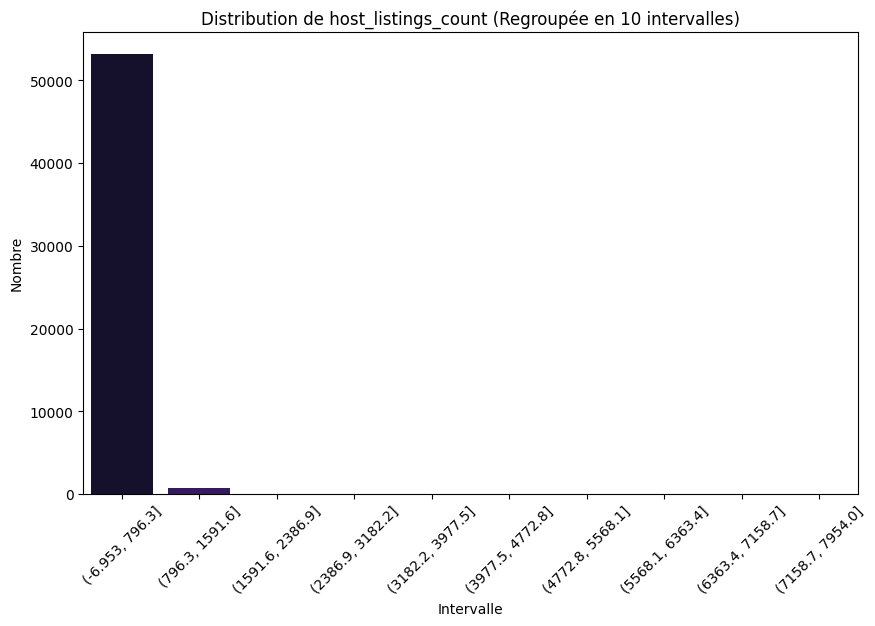

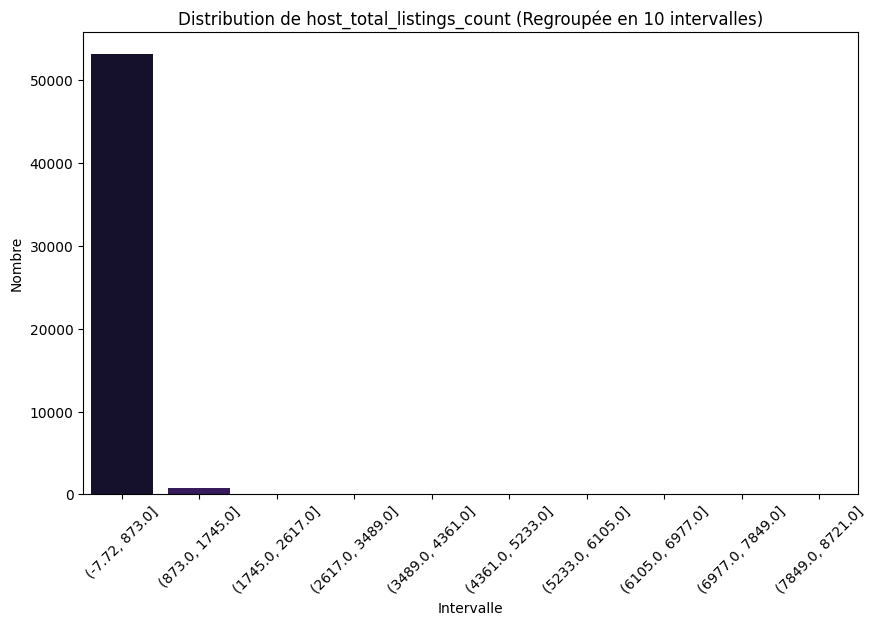

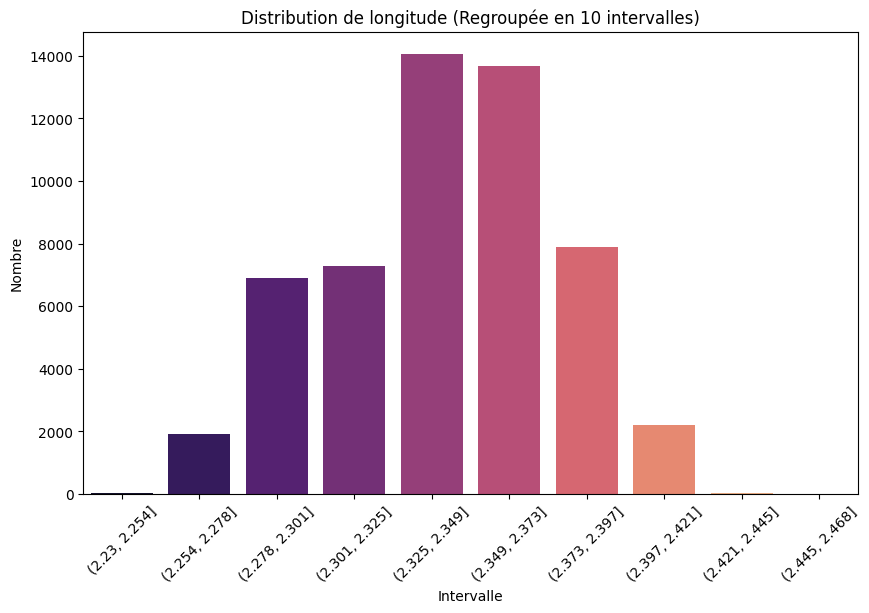

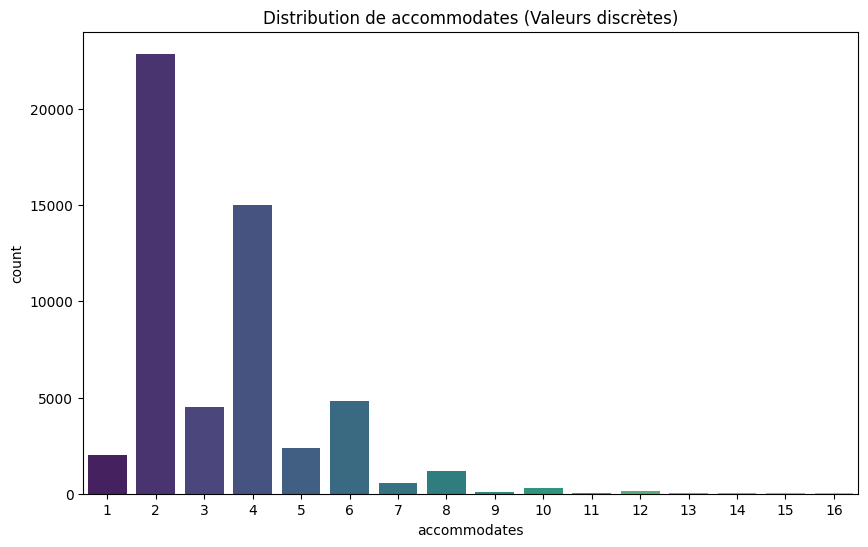

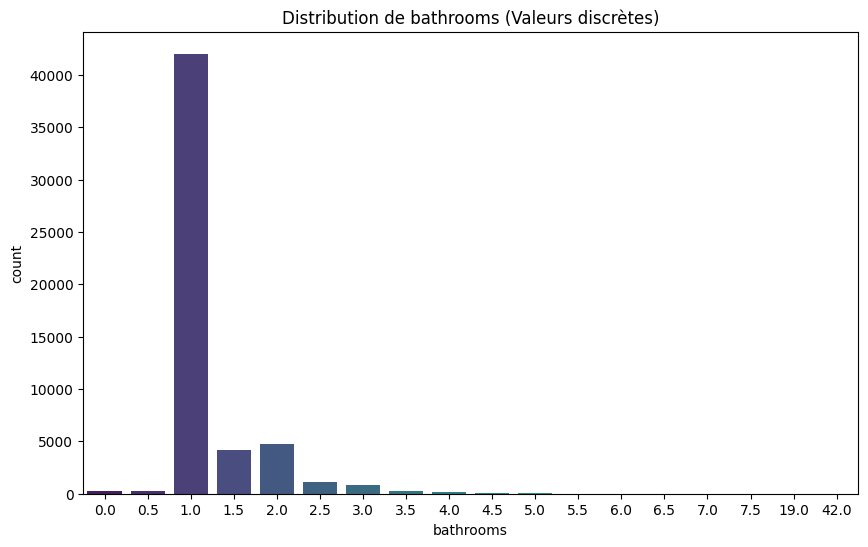

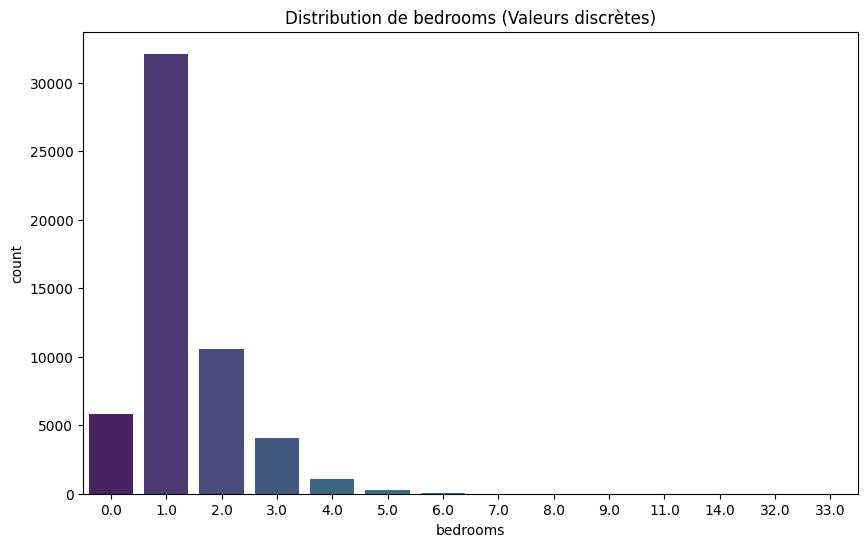

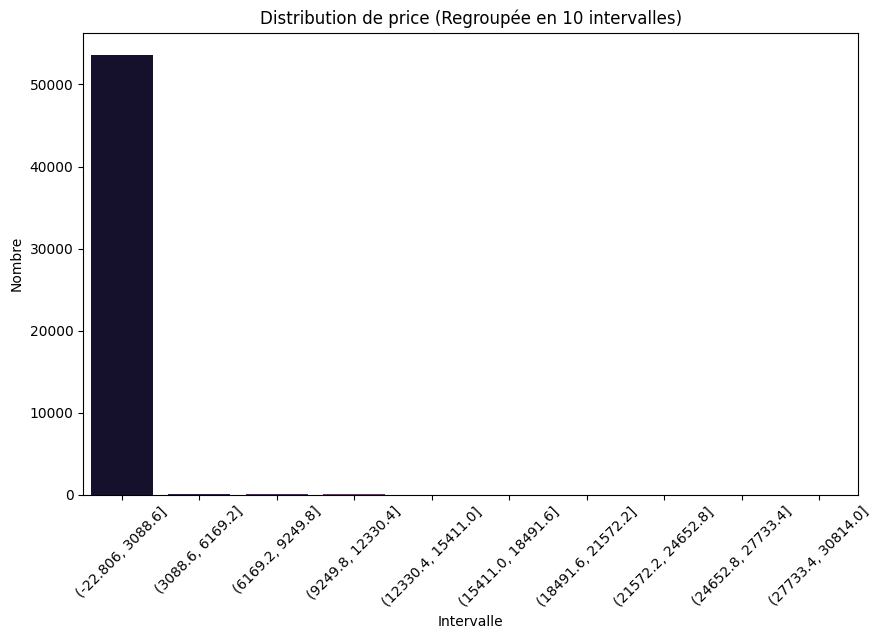

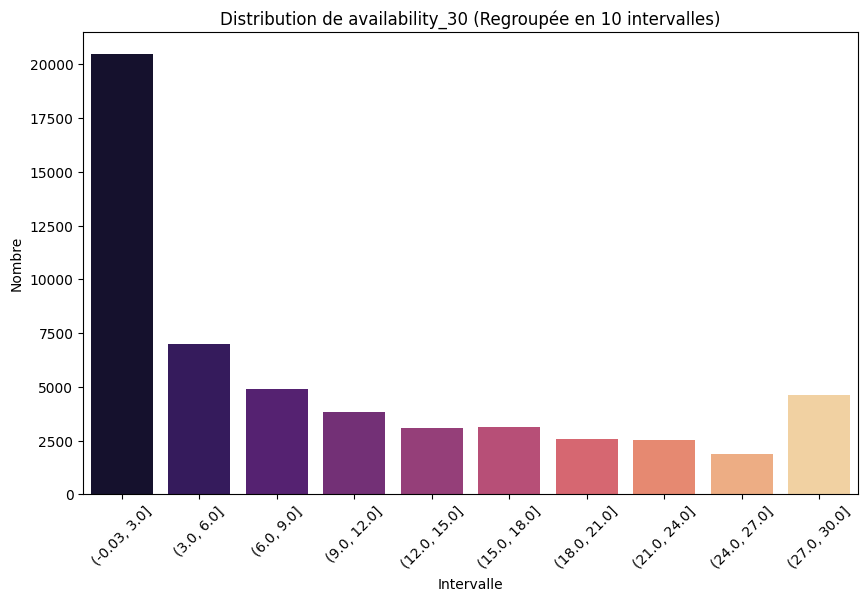

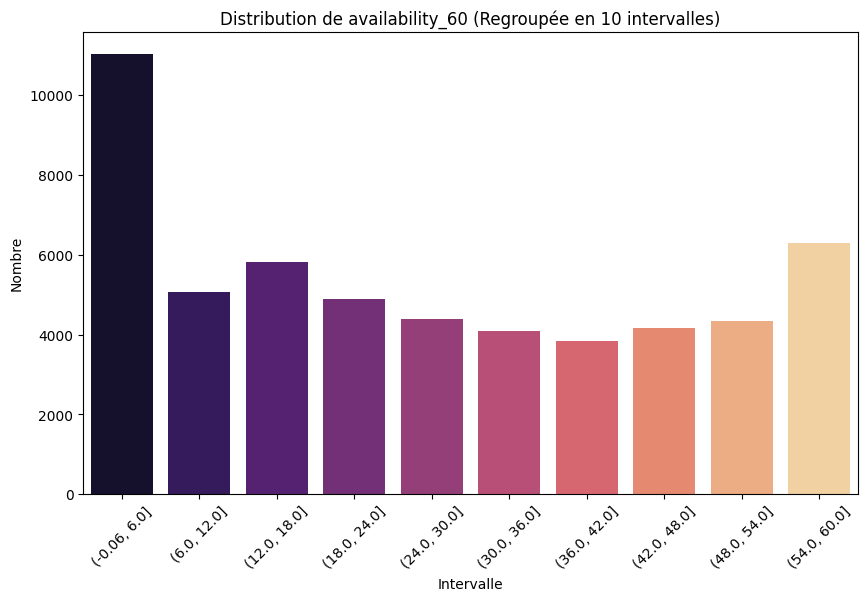

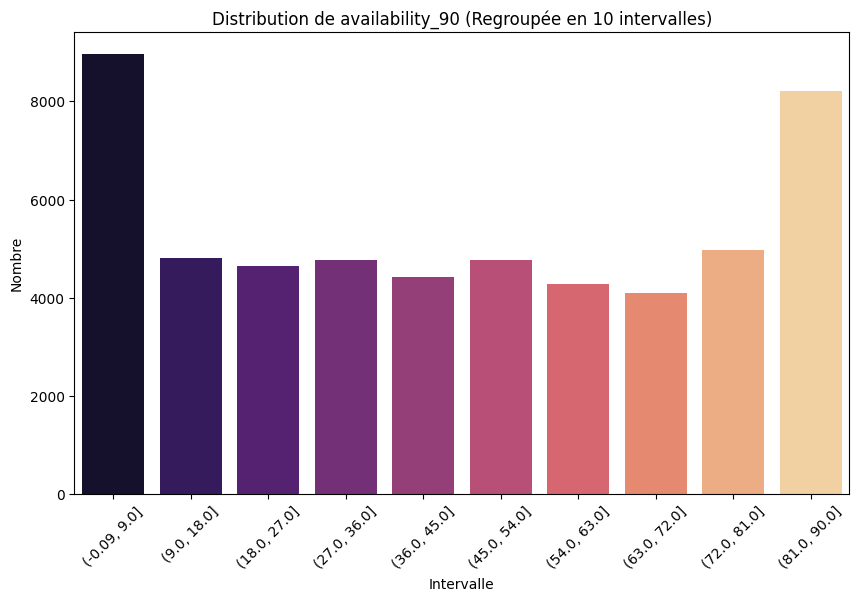

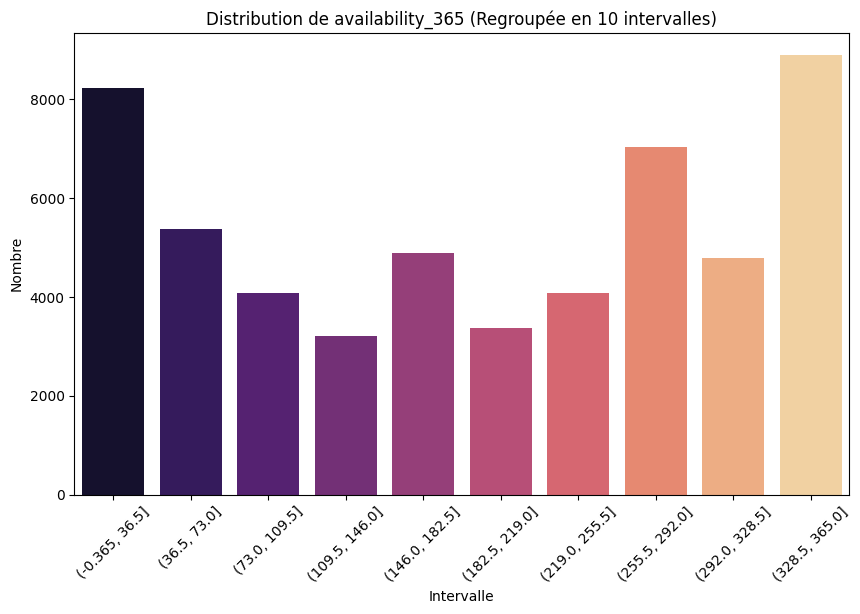

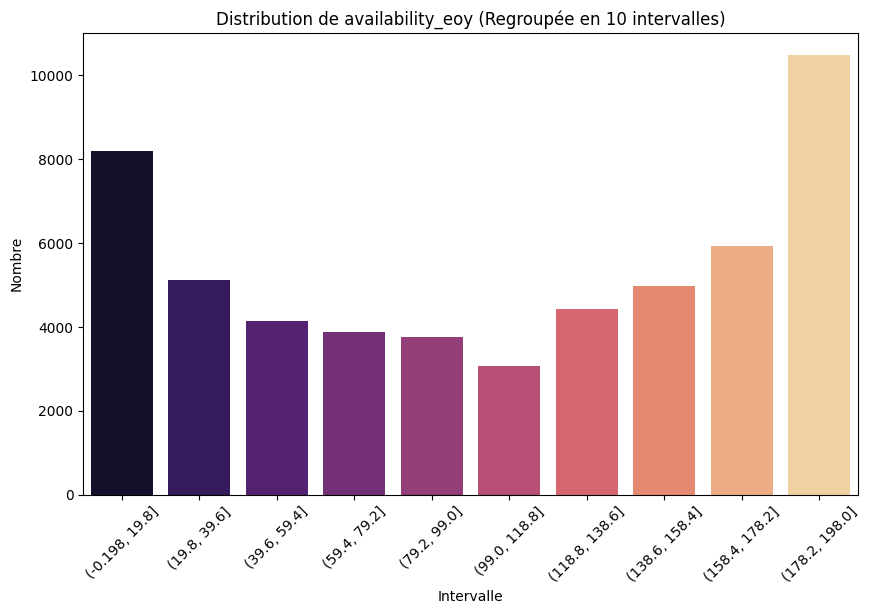

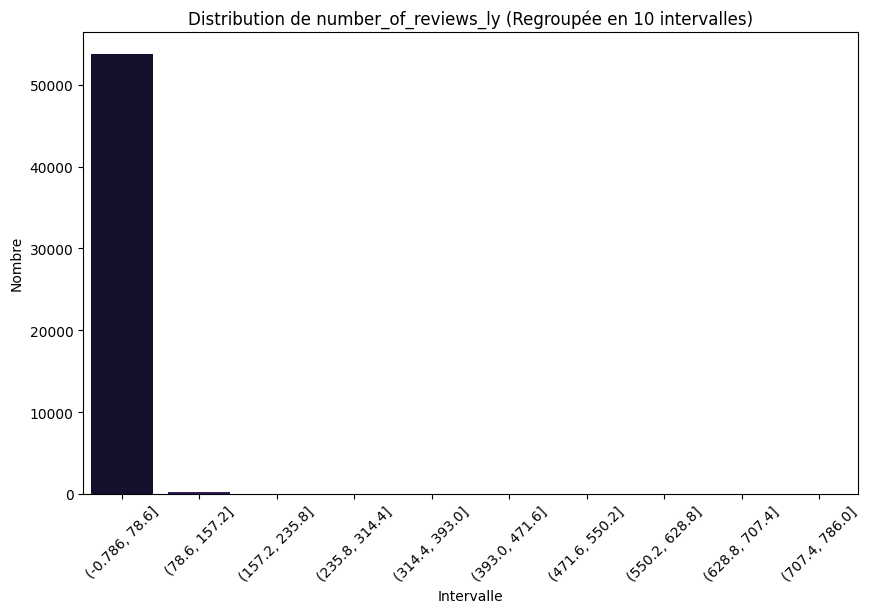

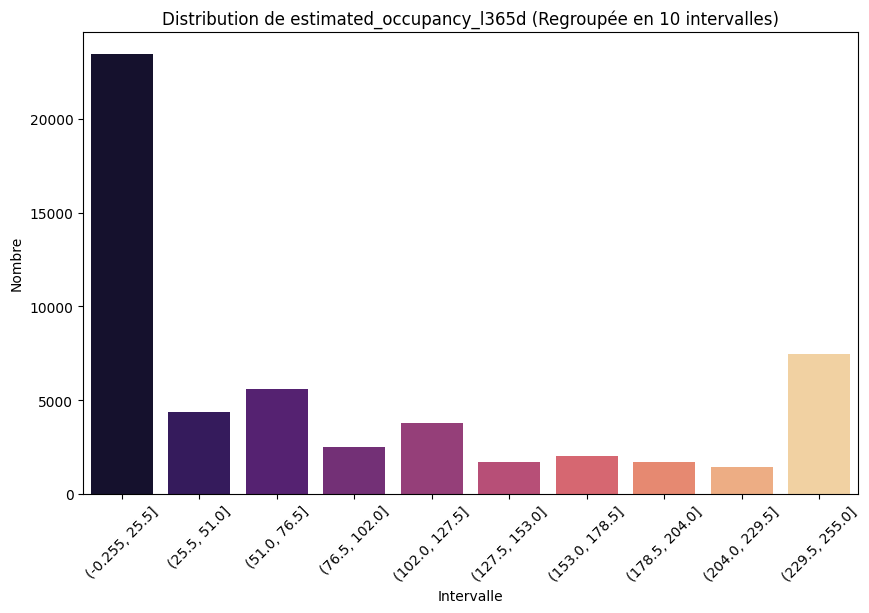

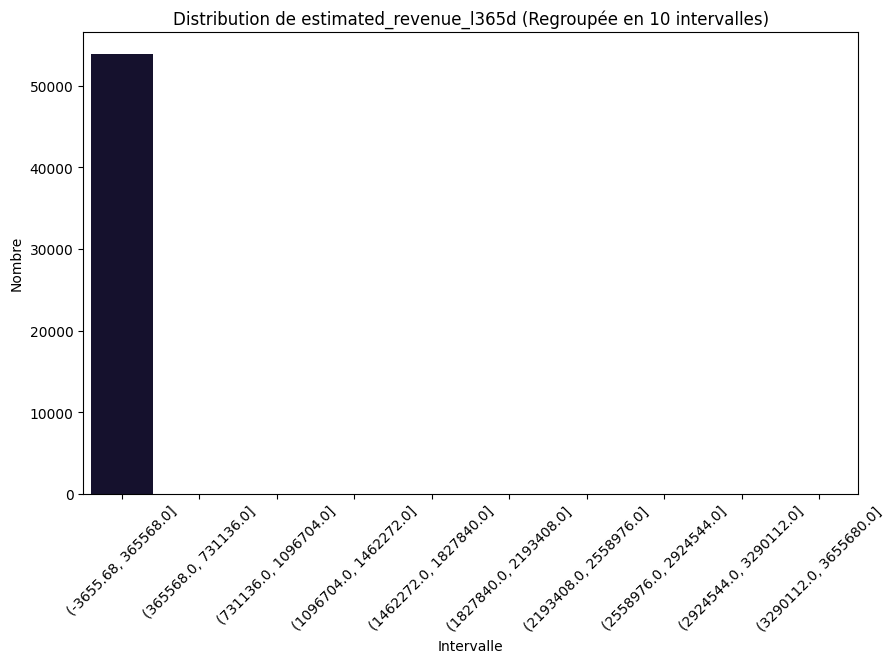

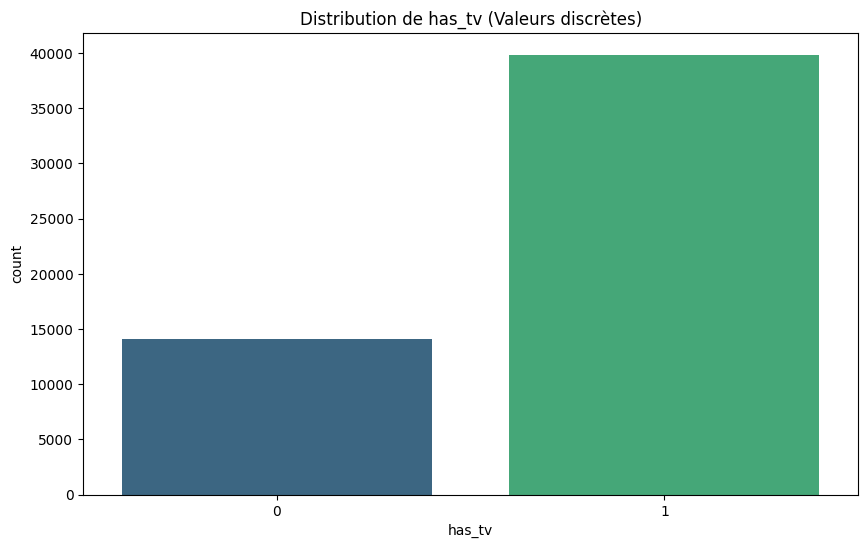

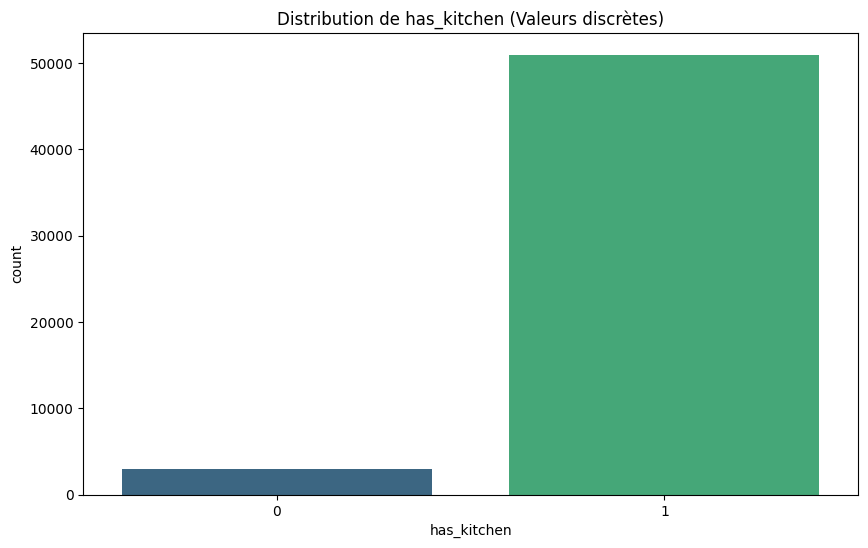

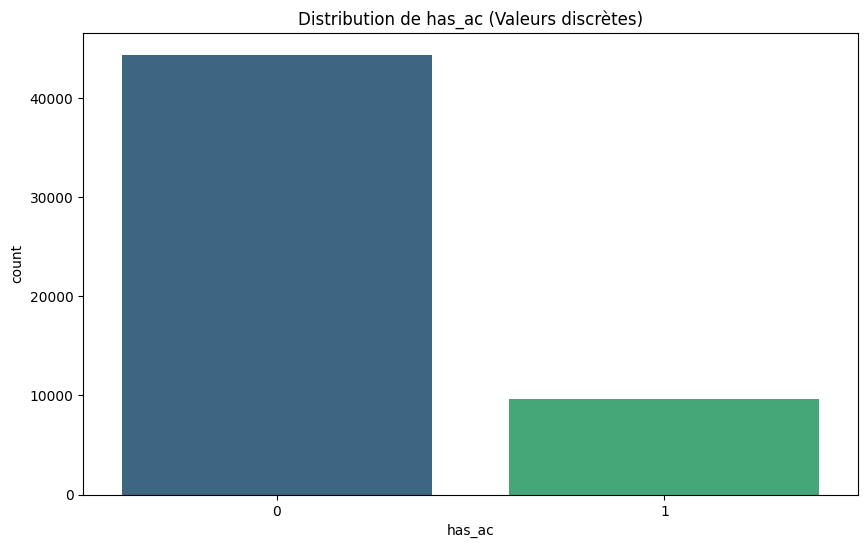

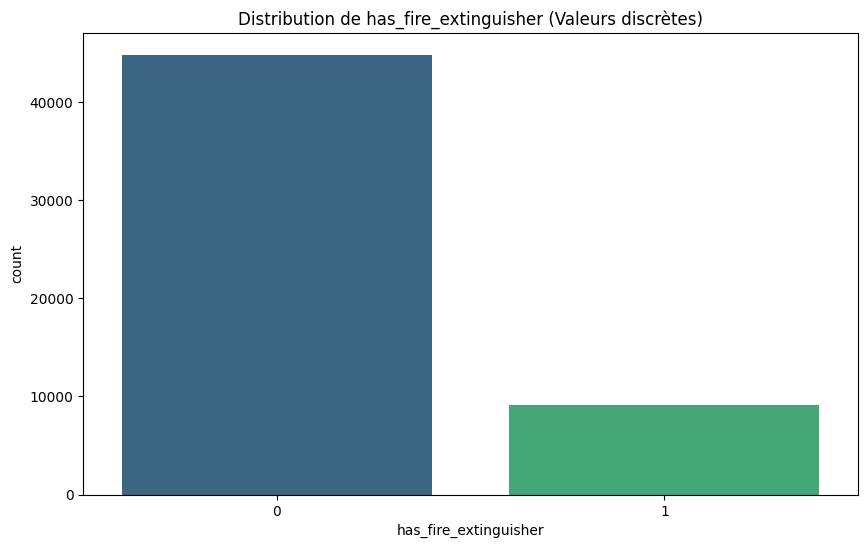

In [31]:
# Liste des variables textuelles intéressantes à explorer
cols_texte = df_final.select_dtypes(include=['object']).columns

for col in cols_texte:
    if col not in df_final.columns:
        continue
        
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)

    if col == 'property_type':
        top_10 = df_final[col].value_counts().nlargest(10).index
        data_to_plot = df_final[df_final[col].isin(top_10)]
        sns.countplot(data=data_to_plot, y=col, order=top_10, palette='Blues_r')
        plt.title(f"Volume : Top 10 {col}")
    else:
        sns.countplot(data=df_final, x=col, palette='Blues_r')
        plt.xticks(rotation=45)
        plt.title(f"Volume par {col}")
        
    plt.ylabel("Nombre de logements")

    plt.subplot(1, 2, 2)
    
    if col == 'property_type':
        sns.barplot(data=data_to_plot, y=col, x='price', estimator=np.median, errorbar=None, order=top_10, palette='viridis')
        plt.title(f"Prix médian : Top 10 {col}")
        plt.xlabel("Prix médian (€)")
    else:
        sns.barplot(data=df_final, x=col, y='price', estimator=np.median, errorbar=None, palette='viridis')
        plt.xticks(rotation=45)
        plt.title(f"Prix médian par {col}")
        plt.ylabel("Prix médian (€)")

    plt.tight_layout()
    plt.show()

In [ ]:
# Histogrammes des features numériques
num_cols = df_final.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(10, 6))
    
    if df_final[col].nunique() <= 20:
        sns.countplot(x=df_final[col], data=df_final, palette='viridis')
        plt.title(f'Distribution de {col} (Valeurs discrètes)')
        
    else:
        bins = pd.cut(df_final[col], bins=10)
        counts = bins.value_counts().sort_index()
        
        df_plot = pd.DataFrame({'Intervalle': counts.index.astype(str), 'Nombre': counts.values})
        
        sns.barplot(data=df_plot, x='Intervalle', y='Nombre', palette='magma')
        plt.title(f'Distribution de {col} (Regroupée en 10 intervalles)')
        plt.xticks(rotation=45)

    plt.show()


In [ ]:
df_final.shape

### Split des données

In [ ]:
cols_features = [col for col in df_final.columns if col != 'price']
X = df_final[cols_features]
y = df_final['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X.shape, y.shape

### Transformation des données

In [ ]:
# num_cols = [*cols_features, 'price'] 
cat_cols = [
   'room_type',
   'neighbourhood_cleansed',
   'property_type',
   'host_response_time',
]
num_cols = df_final[cols_features].select_dtypes(include=['int64', 'float64']).columns

# Tranformations
num_pipeline = Pipeline([
  ('imputer', SimpleImputer(strategy='median')),
  ('scaler', StandardScaler()),
])
cat_pipeline = Pipeline([
  ('imputer', SimpleImputer(strategy='constant', fill_value='Unknow')),
  ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Préprocessing
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
])


### Modèles

In [ ]:
# Train
kf = KFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'LogisticRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'KNeighbors': KNeighborsRegressor(n_neighbors=5),
}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe_log = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    scores = cross_val_score(pipe_log, X_train, y_train, cv=kf, scoring='r2')
    print(f"{name:25s} R² = {scores.mean():.4f} ± {scores.std():.4f}")

In [ ]:

MODELES = {
    'LinearRegression (Baseline)': TransformedTargetRegressor(
        regressor=LinearRegression(),
        func=np.log1p, inverse_func=np.expm1,
    ),
    'Ridge': TransformedTargetRegressor(
        regressor=Ridge(alpha=10.0),
        func=np.log1p, inverse_func=np.expm1,
    ),
    'Lasso': TransformedTargetRegressor(
        regressor=Lasso(alpha=0.01, random_state=SEED),
        func=np.log1p, inverse_func=np.expm1,
    ),
    
    'HistGradientBoosting': TransformedTargetRegressor(
        regressor=HistGradientBoostingRegressor(
            max_iter=200, max_depth=5, learning_rate=0.1,
            min_samples_leaf=10, random_state=SEED),
        func=np.log1p, inverse_func=np.expm1
    ),
    'RandomForest': TransformedTargetRegressor(
        regressor=RandomForestRegressor(
            n_estimators=100, max_depth=12, min_samples_leaf=5, 
            random_state=SEED, n_jobs=-1),
        func=np.log1p, inverse_func=np.expm1
    ),
    'KNeighbors': TransformedTargetRegressor(
        regressor=KNeighborsRegressor(n_neighbors=7, n_jobs=-1),
        func=np.log1p, inverse_func=np.expm1
    ),
    'GradientBoosting': TransformedTargetRegressor(
        regressor=GradientBoostingRegressor(
            n_estimators=200, max_depth=5, learning_rate=0.1,
            min_samples_leaf=10, subsample=0.8, random_state=SEED),
        func=np.log1p, inverse_func=np.expm1
    ),
}

print("Cross-Validation 5-fold en cours...\n")
resultats_cv = {}

for nom, modele in MODELES.items():
    print(f"   {nom}...", end=' ', flush=True)
    
    start_time = time.time()
    
    pipeline_cv = Pipeline([('preprocessor', preprocessor), ('model', modele)])
    scores = cross_validate(
        pipeline_cv, X_train, y_train,
        cv=5,
        scoring=('neg_mean_absolute_error', 'r2'),
    )
    
    elapsed_time = time.time() - start_time
    
    mae_mean = -scores['test_neg_mean_absolute_error'].mean()
    mae_std  =  scores['test_neg_mean_absolute_error'].std()
    r2_mean  =  scores['test_r2'].mean()
    r2_std   =  scores['test_r2'].std()
    
    resultats_cv[nom] = {
        'MAE_mean': mae_mean, 'MAE_std': mae_std,
        'R2_mean': r2_mean,   'R2_std': r2_std,
        'Temps': elapsed_time
    }
    print(f"MAE = {mae_mean:.2f}€ (±{mae_std:.2f}€)   R² = {r2_mean:.4f} (±{r2_std:.4f}) | Time: {elapsed_time:.2f}s")

print("\nCross-Validation terminée !")
print("\n TABLEAU RÉCAPITULATIF (mean ± std) :")
header = f"{'Modèle':<40} {'MAE (€)':>15}  {'R²':>18} {'Temps':>12}"
print(header)
print('-' * len(header))
for nom, res in resultats_cv.items():
    print(f"{nom:<40} {res['MAE_mean']:6.2f} ± {res['MAE_std']:5.2f}  {res['R2_mean']:.4f} ± {res['R2_std']:.4f} {res['Temps']:10.2f}s")

## Tuning

In [ ]:
pipeline_hgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', TransformedTargetRegressor(
        regressor=HistGradientBoostingRegressor(random_state=SEED),
        func=np.log1p, inverse_func=np.expm1,
    )),
]) 
param_grid = {
    'model__regressor__max_iter':         [100, 200, 300, 500],
    'model__regressor__max_depth':        [3, 5, 7, 10, None],
    'model__regressor__learning_rate':    [0.01, 0.05, 0.08, 0.1, 0.15],
    'model__regressor__min_samples_leaf': [5, 10, 20, 30],
    'model__regressor__l2_regularization': [0.0, 0.1, 1.0, 10.0],
} 
scoring_metrics = {
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2',
    'RMSE': 'neg_root_mean_squared_error'
}

print("RandomizedSearchCV pour HistGradientBoosting avec multi-scoring...")

searcher = RandomizedSearchCV(
    estimator=pipeline_hgb,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring=scoring_metrics,
    refit='MAE',
    random_state=SEED,
    verbose=1,
)

# Lancement de la recherche
searcher.fit(X_train, y_train)

# Récupération du meilleur pipeline (basé sur la MAE, comme défini dans refit)
best_pipeline = searcher.best_estimator_

print(f"\n✅ Tuning terminé !")
print(f"\n🏆 Meilleurs hyperparamètres :")
for k, v in sorted(searcher.best_params_.items()):
    clean_key = k.replace('model__regressor__', '')
    print(f"  {clean_key:30s} = {v}")

# Extraction des scores associés au meilleur modèle trouvé
best_index = searcher.best_index_

# On multiplie par -1 pour réafficher des valeurs d'erreur positives
mae_score = -searcher.cv_results_['mean_test_MAE'][best_index]
r2_score = searcher.cv_results_['mean_test_R2'][best_index]
rmse_score = -searcher.cv_results_['mean_test_RMSE'][best_index]

print(f"\nPerformances du meilleur modèle (Scores CV moyens) :")
print(f"  MAE  : {mae_score:.2f} €")
print(f"  R²   : {r2_score:.4f}")
print(f"  RMSE : {rmse_score:.2f} €")

## Métriques

In [ ]:
y_pred = best_pipeline.predict(X_test)

# 2. On compare ses réponses (y_pred) avec la réalité (y_test)
mae_finale = mean_absolute_error(y_test, y_pred)
r2_final = r2_score_f(y_test, y_pred) # Utilisation du nouveau nom de fonction
rmse_final = root_mean_squared_error(y_test, y_pred)

# 3. Affichage
print("=== RÉSULTATS DE L'EXAMEN FINAL ===")
print(f"La MAE finale est de  : {mae_finale:.2f} €")
print(f"Le R² final est de    : {r2_final:.4f}")
print(f"Le RMSE final est de  : {rmse_final:.2f} €")

print(f"\nExplication : 'Sur des appartements qu'il n'a jamais vus, notre IA se trompe en moyenne de {mae_finale:.2f} € par nuit.'")

## Save

In [ ]:
# chemins de fichiers
class_name = "AirBnbPriceDetecParisBoost_v1"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

base_dir = "model"
save_dir = os.path.join(base_dir, f"{class_name}_{timestamp}")

os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "model.joblib")
metrics_path = os.path.join(save_dir, "metrics.json")

In [ ]:
# --- EXPORT DU MODÈLE (.joblib) ---
# On sauvegarde notre meilleur modèle complet (qui contient le preprocessor ET l'algorithme)
joblib.dump(best_pipeline, model_path)
print(f"Modèle sauvegardé sous : {model_path}")

In [ ]:
# ---  EXPORT DES MÉTRIQUES (.json) ---
metrics_dict = {
  "model": "RandomForestRegressor (Tuned)",
  "metric_main": {"name": "MAE", "value": round(mae_finale, 2), "unit": "€"},
  "cv_results": {"mean": round(-searcher.best_score_, 2), "std": "N/A"},
  "date_entrainement": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
  "metrics_test": {"MAE": round(mae_finale, 2),"R2": round(r2_final, 4),"RMSE": round(rmse_final, 2)},
  "test_size": 0.2,
  "random_state": 42
}

with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics_dict, f, indent=4, ensure_ascii=False)
    
print(f"Métriques sauvegardées sous : {metrics_path}")